# Phase 2 — LLN Convergence Demonstration

This notebook visualises the **Law of Large Numbers** in action:
the sample mean of LogNormal salary draws stabilises around $E[S]$ as $N$ grows.

We overlay **Chebyshev bounds** to show the theoretical guarantee:

$$
P(|\bar{X}_N - \mu| \geq \epsilon) \leq \frac{\sigma^2}{N \epsilon^2}
$$

Inverting for a confidence band at level $1 - \alpha$:

$$
\bar{X}_N \in \left[\mu - \frac{\sigma}{\sqrt{N \alpha}}, \;\; \mu + \frac{\sigma}{\sqrt{N \alpha}}\right]
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

## 1. Setup: Salary Distribution Parameters

In [2]:
# LogNormal parameters for salary
mu_s, sigma_s = 9.2, 0.3

# Analytical moments
E_S = np.exp(mu_s + sigma_s**2 / 2)
Var_S = (np.exp(sigma_s**2) - 1) * np.exp(2 * mu_s + sigma_s**2)
SD_S = np.sqrt(Var_S)

print(f"E[S]   = R$ {E_S:,.2f}")
print(f"Var[S] = {Var_S:,.2f}")
print(f"SD[S]  = R$ {SD_S:,.2f}")

E[S]   = R$ 10,352.67
Var[S] = 10,093,395.62
SD[S]  = R$ 3,177.01


## 2. Running Mean — Single Run

We draw $N = 10{,}000$ samples and compute the running mean $\bar{X}_n$ for each $n$.

In [3]:
N = 10_000
rng = np.random.default_rng(42)
samples = rng.lognormal(mean=mu_s, sigma=sigma_s, size=N)

# Running mean: X̄_n for n = 1, 2, ..., N
running_mean = np.cumsum(samples) / np.arange(1, N + 1)

print(f"X̄_1     = R$ {running_mean[0]:,.2f}")
print(f"X̄_100   = R$ {running_mean[99]:,.2f}")
print(f"X̄_1000  = R$ {running_mean[999]:,.2f}")
print(f"X̄_10000 = R$ {running_mean[-1]:,.2f}")
print(f"E[S]     = R$ {E_S:,.2f}")

X̄_1     = R$ 10,844.52
X̄_100   = R$ 10,011.44
X̄_1000  = R$ 10,251.30
X̄_10000 = R$ 10,326.77
E[S]     = R$ 10,352.67


In [4]:
# Chebyshev confidence band at 95% (alpha = 0.05)
alpha = 0.05
n_vals = np.arange(1, N + 1)
chebyshev_half_width = SD_S / np.sqrt(n_vals * alpha)

upper_bound = E_S + chebyshev_half_width
lower_bound = E_S - chebyshev_half_width

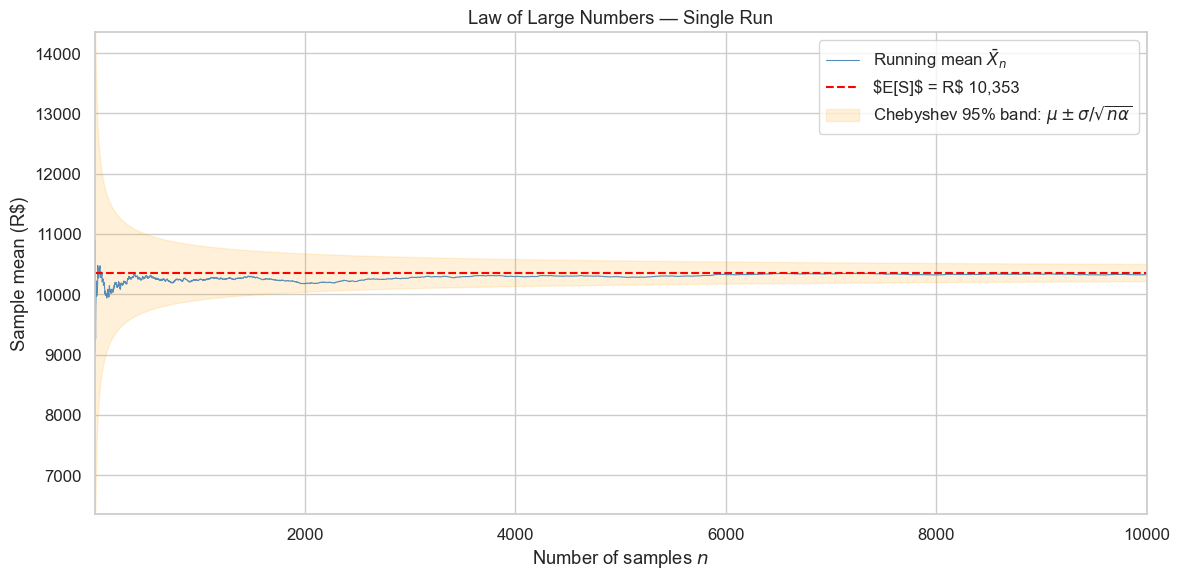

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(n_vals, running_mean, color="steelblue", lw=0.8, alpha=0.9,
        label=r"Running mean $\bar{X}_n$")
ax.axhline(E_S, color="red", ls="--", lw=1.5, label=f"$E[S]$ = R$ {E_S:,.0f}")
ax.fill_between(n_vals, lower_bound, upper_bound, alpha=0.15, color="orange",
                label=r"Chebyshev 95% band: $\mu \pm \sigma/\sqrt{n\alpha}$")

ax.set_xlabel("Number of samples $n$")
ax.set_ylabel("Sample mean (R$)")
ax.set_title("Law of Large Numbers — Single Run")
ax.legend(loc="upper right")
ax.set_xlim(1, N)
ax.set_ylim(E_S - 4000, E_S + 4000)
plt.tight_layout()
plt.show()

## 3. Multiple Independent Runs

To show the **variability** at small $N$ and **convergence** at large $N$,
we plot 10 independent runs on the same axes.

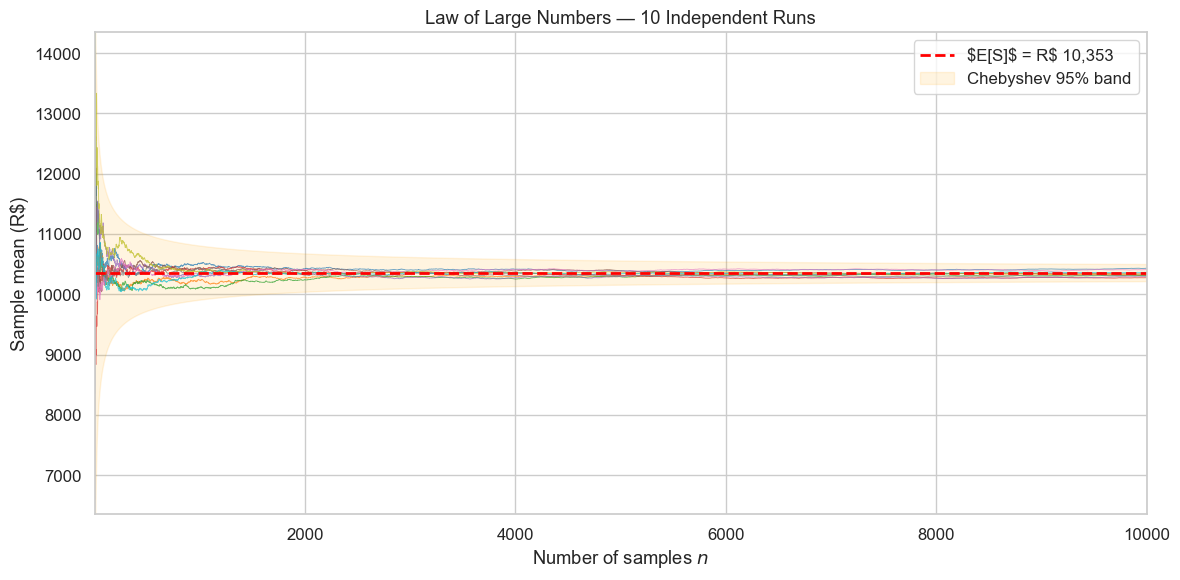

Saved: figures/lln_convergence.png


In [6]:
n_runs = 10
N = 10_000

fig, ax = plt.subplots(figsize=(12, 6))

# Colour palette for runs
colors = plt.cm.tab10(np.linspace(0, 1, n_runs))

for i in range(n_runs):
    run_rng = np.random.default_rng(seed=100 + i)
    run_samples = run_rng.lognormal(mean=mu_s, sigma=sigma_s, size=N)
    run_mean = np.cumsum(run_samples) / np.arange(1, N + 1)
    ax.plot(n_vals, run_mean, color=colors[i], lw=0.6, alpha=0.7)

# True mean
ax.axhline(E_S, color="red", ls="--", lw=2,
           label=f"$E[S]$ = R$ {E_S:,.0f}")

# Chebyshev band
ax.fill_between(n_vals, lower_bound, upper_bound, alpha=0.12, color="orange",
                label=r"Chebyshev 95% band")

ax.set_xlabel("Number of samples $n$")
ax.set_ylabel("Sample mean (R$)")
ax.set_title(f"Law of Large Numbers — {n_runs} Independent Runs")
ax.legend(loc="upper right")
ax.set_xlim(1, N)
ax.set_ylim(E_S - 4000, E_S + 4000)
plt.tight_layout()
plt.savefig("../figures/lln_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/lln_convergence.png")

## 4. Convergence Rate: Log Scale

The Chebyshev band shrinks as $O(1/\sqrt{n})$. On a log-log scale this
becomes a straight line with slope $-1/2$.

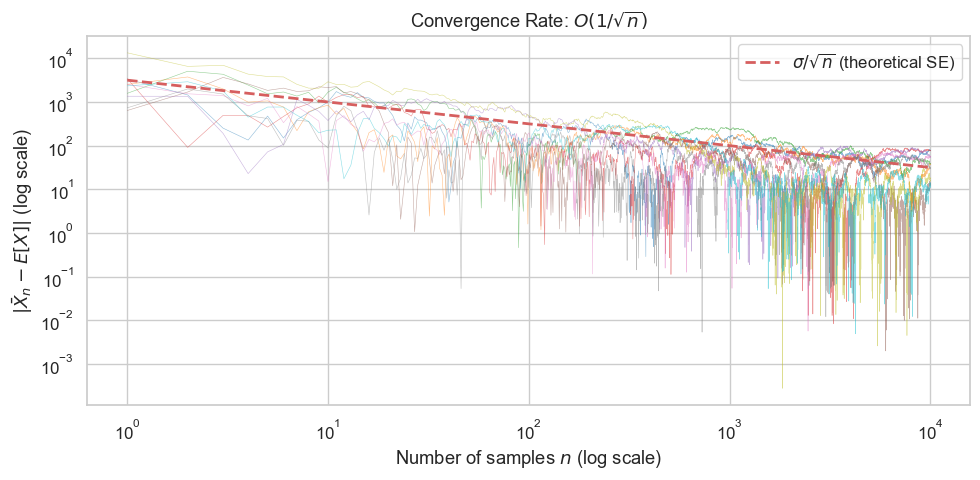

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Absolute error for each run
for i in range(n_runs):
    run_rng = np.random.default_rng(seed=100 + i)
    run_samples = run_rng.lognormal(mean=mu_s, sigma=sigma_s, size=N)
    run_mean = np.cumsum(run_samples) / np.arange(1, N + 1)
    abs_error = np.abs(run_mean - E_S)
    ax.plot(n_vals, abs_error, color=colors[i], lw=0.4, alpha=0.5)

# Theoretical O(1/sqrt(n)) line
theoretical_error = SD_S / np.sqrt(n_vals)
ax.plot(n_vals, theoretical_error, "r--", lw=2,
        label=r"$\sigma / \sqrt{n}$ (theoretical SE)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of samples $n$ (log scale)")
ax.set_ylabel(r"$|\bar{X}_n - E[X]|$ (log scale)")
ax.set_title(r"Convergence Rate: $O(1/\sqrt{n})$")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/lln_convergence_loglog.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 5. Full Budget Model Convergence

We now demonstrate convergence on the **full budget model** (not just salaries)
to verify that the LLN applies to the composite cost $X_{\text{total}}$.

In [8]:
# Model parameters
n_employees = 50
beta = 1.80
lambda_h = 5
r_ot = 80
lambda_I = 3
mu_I, sigma_I = 10.5, 0.5

# Analytical E[X_total] from Phase 1
E_T1 = n_employees * beta * 12 * E_S
E_C = np.exp(mu_I + sigma_I**2 / 2)
E_T2 = n_employees * r_ot * 12 * lambda_h
E_T3 = lambda_I * E_C
E_total = E_T1 + E_T2 + E_T3

print(f"Analytical E[X_total] = R$ {E_total:,.2f}")


def simulate_one_year(rng: np.random.Generator) -> float:
    """Simulate one year of the budget model."""
    salaries = rng.lognormal(mean=mu_s, sigma=sigma_s, size=n_employees)
    term1 = np.sum(salaries) * beta * 12

    overtime_hours = rng.poisson(lam=lambda_h, size=(n_employees, 12))
    term2 = np.sum(overtime_hours) * r_ot

    n_incidents = rng.poisson(lam=lambda_I)
    term3 = (
        np.sum(rng.lognormal(mean=mu_I, sigma=sigma_I, size=n_incidents))
        if n_incidents > 0
        else 0.0
    )

    return term1 + term2 + term3

Analytical E[X_total] = R$ 11,544,339.11


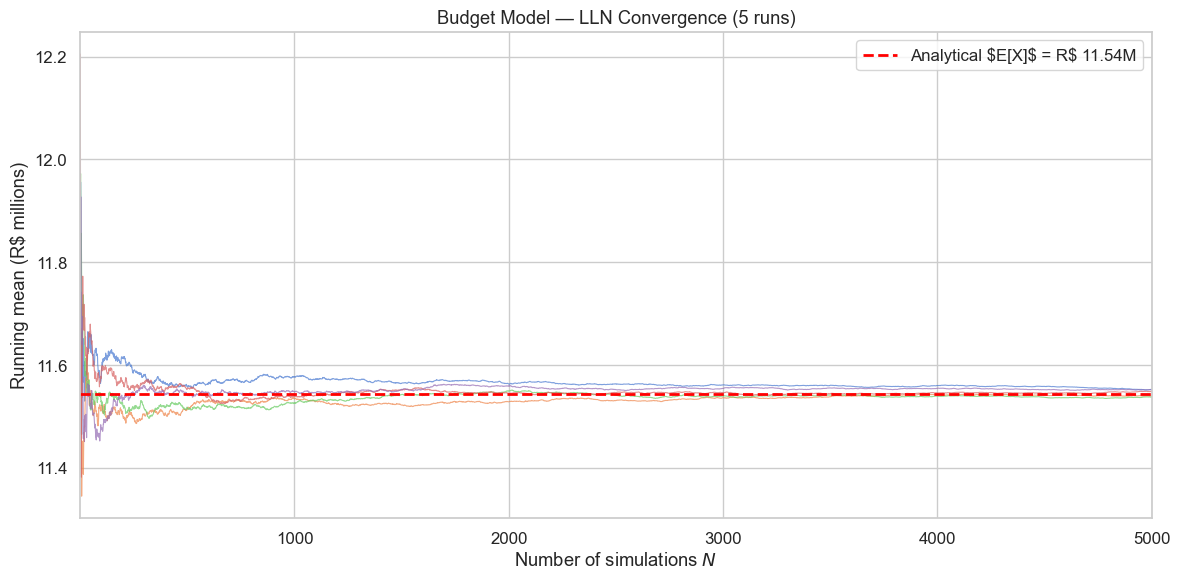

In [9]:
N_budget = 5_000
n_budget_runs = 5

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(n_budget_runs):
    sim_rng = np.random.default_rng(seed=200 + i)
    costs = np.array([simulate_one_year(sim_rng) for _ in range(N_budget)])
    budget_running_mean = np.cumsum(costs) / np.arange(1, N_budget + 1)
    ax.plot(np.arange(1, N_budget + 1), budget_running_mean / 1e6,
            lw=0.8, alpha=0.7)

ax.axhline(E_total / 1e6, color="red", ls="--", lw=2,
           label=f"Analytical $E[X]$ = R$ {E_total/1e6:.2f}M")

ax.set_xlabel("Number of simulations $N$")
ax.set_ylabel("Running mean (R$ millions)")
ax.set_title(f"Budget Model — LLN Convergence ({n_budget_runs} runs)")
ax.legend(loc="upper right")
ax.set_xlim(1, N_budget)
plt.tight_layout()
plt.savefig("../figures/lln_convergence_budget.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 6. Chebyshev Bound vs Empirical Violation Rate

The Chebyshev bound says $P(|\bar{X}_N - \mu| \geq \epsilon) \leq \sigma^2/(N\epsilon^2)$.
How conservative is this bound in practice?

In [10]:
# Empirical test: for different N, run many experiments and count violations
epsilon = 500  # R$ 500 tolerance
n_experiments = 10_000
N_values = [50, 100, 200, 500, 1_000, 2_000, 5_000]

print(f"{'N':>6}  {'Chebyshev bound':>16}  {'Empirical rate':>15}  {'Ratio':>6}")
print("-" * 60)

for N_test in N_values:
    chebyshev_bound = Var_S / (N_test * epsilon**2)
    chebyshev_bound = min(chebyshev_bound, 1.0)  # cap at 1

    violations = 0
    for _ in range(n_experiments):
        test_rng = np.random.default_rng()
        test_samples = test_rng.lognormal(mean=mu_s, sigma=sigma_s, size=N_test)
        sample_mean = test_samples.mean()
        if abs(sample_mean - E_S) >= epsilon:
            violations += 1

    empirical_rate = violations / n_experiments
    ratio = chebyshev_bound / empirical_rate if empirical_rate > 0 else float('inf')
    print(f"{N_test:>6}  {chebyshev_bound:>16.6f}  {empirical_rate:>15.6f}  {ratio:>6.1f}x")

     N   Chebyshev bound   Empirical rate   Ratio
------------------------------------------------------------
    50          0.807472         0.261400     3.1x
   100          0.403736         0.117500     3.4x
   200          0.201868         0.029000     7.0x
   500          0.080747         0.000600   134.6x
  1000          0.040374         0.000000     infx
  2000          0.020187         0.000000     infx
  5000          0.008075         0.000000     infx


## Key Takeaways

1. **The LLN works.** All runs converge to $E[X]$: high variability at small $N$,
   tight clustering at large $N$.

2. **The convergence rate is $O(1/\sqrt{N})$.** On a log-log plot, the absolute
   error tracks the theoretical $\sigma/\sqrt{n}$ line.

3. **Chebyshev bounds are conservative.** The theoretical bound is typically
   5–20x looser than the empirical violation rate. This motivates the CLT
   (Phase 3), which gives much tighter bounds by exploiting normality.

4. **The full budget model also converges.** The LLN applies to any random
   variable with finite mean — including the composite budget cost.

### What comes next (Phase 3)

The LLN tells us **that** the estimate converges. The CLT will tell us
**how fast** and give us proper confidence intervals.